# Figure 7

This notebook reproduces four panels.

In [1]:
from pathlib import Path
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore', message='IProgress not found.*')
import shap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from PIL import Image as PILImage
from IPython.display import Image as NotebookImage, display

plt.rcParams.update({
    'figure.dpi': 500,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'data_analysis' / 'data' / 'analysis_data.xlsx').exists():
            return candidate
    raise FileNotFoundError('Could not locate data_analysis/data/analysis_data.xlsx.')

ROOT = find_repository_root()
DATA_FILE = ROOT / 'data_analysis' / 'data' / 'analysis_data.xlsx'
FIGURE_DIR = ROOT / 'data_analysis' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print('Repository root:', ROOT)


Repository root: C:\Users\zh509\OneDrive - University of Illinois - Urbana\A\P5 collab LCML\Chiral-LLC-ML-main


In [2]:
feature_table = pd.read_excel(DATA_FILE, sheet_name='Exp_ML_features')
metadata_table = pd.read_excel(DATA_FILE, sheet_name='Exp_ML_metadata')
if not feature_table['experiment_id'].equals(metadata_table['experiment_id']):
    raise ValueError('Exp_ML_features and Exp_ML_metadata are not aligned by experiment_id.')
if feature_table['experiment_id'].duplicated().any() or len(feature_table) != 773:
    raise ValueError('Expected 773 uniquely keyed experimental rows.')

features_all = feature_table.drop(columns='experiment_id').reset_index(drop=True)
metadata = metadata_table[['abs_g_factor', 'family', 'polymer']].rename(columns={
    'family': 'Family', 'polymer': 'Polymer'
}).reset_index(drop=True)
rowmap = pd.DataFrame({
    'RowPos': np.arange(len(metadata_table)),
    'Family': metadata_table['family'],
    'Polymer name': metadata_table['polymer'],
    'Solvent': metadata_table['solvent'],
    'Assemble Type': metadata_table['assembly_type'],
    'Temperature': metadata_table['temperature_C'],
    'Concentration_mg_mL': metadata_table['concentration_mg_mL'],
})

family_columns = [column for column in features_all if column.startswith('family_')]
if not features_all[family_columns].sum(axis=1).eq(1).all():
    raise ValueError('Each experimental row must have exactly one family indicator.')
print(f'Experimental v6x data aligned: {len(features_all)} rows')


Experimental v6x data aligned: 773 rows


In [3]:
STRONG = 'Strongly Chiral'
WEAK = 'Weakly Chiral'
ISOTROPIC = 'Isotropic'
AGGREGATION = 'Aggregated'
CATEGORY_ORDER = [STRONG, WEAK, ISOTROPIC, AGGREGATION]
cmap_outcome = LinearSegmentedColormap.from_list(
    'outcome_blue_white_red', [(0, '#008BFB'), (0.5, '#FFFFFF'), (1, '#FF0051')], N=256
)
CATEGORY_TO_COLOR = {
    STRONG: cmap_outcome(0.90), WEAK: cmap_outcome(0.60),
    ISOTROPIC: cmap_outcome(0.35), AGGREGATION: cmap_outcome(0.05),
}
CATEGORY_TO_MARKER = {STRONG: 'o', WEAK: 's', ISOTROPIC: '^', AGGREGATION: 'v'}
CATEGORY_TO_ZORDER = {STRONG: 5, WEAK: 4, ISOTROPIC: 3, AGGREGATION: 2}

plot_df = pd.DataFrame({
    'RowPos': np.arange(len(features_all)),
    'FASTSOLV_monomer': pd.to_numeric(features_all['Monomer_fastsolv'], errors='coerce'),
    'FASTSOLV_backbone': pd.to_numeric(features_all['Backbone_fastsolv'], errors='coerce'),
    'abs_g_factor': pd.to_numeric(metadata['abs_g_factor'], errors='coerce'),
    'Polymer name': rowmap['Polymer name'].to_numpy(),
    'Solvent': rowmap['Solvent'].to_numpy(),
    'Temperature': rowmap['Temperature'].to_numpy(),
    'Concentration_mg_mL': rowmap['Concentration_mg_mL'].to_numpy(),
    'Assemble Type': rowmap['Assemble Type'].to_numpy(),
})

def assign_category(assembly, g_value):
    if pd.isna(assembly) or pd.isna(g_value):
        return np.nan
    assembly = str(assembly).strip().lower()
    if assembly == 'c':
        return STRONG if g_value >= 0.001 else WEAK
    if assembly == 'i':
        return ISOTROPIC
    if assembly == 'a':
        return AGGREGATION
    return np.nan

plot_df['Category'] = [assign_category(a, g) for a, g in zip(plot_df['Assemble Type'], plot_df['abs_g_factor'])]
d_all = plot_df.dropna(subset=['FASTSOLV_monomer', 'FASTSOLV_backbone', 'Category']).copy()
d_all['_Polymer_key'] = d_all['Polymer name'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True).str.lower()
d_all['_Solvent_key'] = d_all['Solvent'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True).str.lower()

feature_columns_to_add = [c for c in features_all if c not in d_all.columns]
d_all_feature = d_all.merge(
    features_all[feature_columns_to_add].assign(RowPos=np.arange(len(features_all))),
    on='RowPos', how='left', validate='one_to_one'
)
print('Outcome counts:')
print(d_all['Category'].value_counts().reindex(CATEGORY_ORDER, fill_value=0))


Outcome counts:
Category
Strongly Chiral    271
Weakly Chiral       36
Isotropic          187
Aggregated         279
Name: count, dtype: int64


In [4]:
DROP_FEATURES = [
    'BB_conjugated_units_Norm_MolWt', 'R_ring_6', 'Monomer_NumHDonors_Norm_MolWt',
    'Monomer_NumHAcceptors_Norm_MolWt', 'SC_atoms_before_plus_after_CO_Norm_MolWt',
    'SideChain_Eccentricity', 'Backbone_Eccentricity', 'Monomer_Eccentricity',
    'R_atom_all', 'SC_bonds_CC_or_CO_Norm_MolWt', 'BB_C_atoms_Norm_MolWt',
    'Backbone_InertialShapeFactor', 'Solvent_Eccentricity', 'Solvent_TPSA',
    'SideChain_TPSA', 'R_ring_3', 'R_ring_1', 'SC_atoms_after_branching_CO_Norm_MolWt',
    'Monomer_InertialShapeFactor', 'SC_total_atoms_CO_Norm_MolWt', 'dG_solv_cosmo',
    'Monomer_NumSpiroAtoms_Norm_MolWt', 'Monomer_NumSaturatedRings_Norm_MolWt',
    'Monomer_NumBridgeheadAtoms_Norm_MolWt', 'MW_Mw', 'SC_C_atoms_Norm_MolWt',
    'BB_CeqC_bonds_Norm_MolWt', 'BB_CC_rotatable_bonds_Norm_MolWt',
    'SC_total_branches_Norm_MolWt', 'SC_atoms_before_branching_CO_Norm_MolWt',
    'Backbone_TPSA', 'BBminusSC_MolLogP', 'SideChain_InertialShapeFactor',
    'BB_rings_total_Norm_MolWt', 'Monomer_NumAromaticRings_Norm_MolWt',
    'SideChain_MolLogP',
]

RF_PARAMS = {
    'n_estimators': 1100,
    'max_depth': 12,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': 0.5,
    'class_weight': 'balanced',
    'bootstrap': True,
    'n_jobs': -1,
}

model_features = features_all.drop(columns=DROP_FEATURES, errors='ignore').copy()

def family_shap_values(family_column, random_state):
    if family_column not in model_features.columns:
        raise KeyError(f"Column '{family_column}' was not found.")

    family_mask = model_features[family_column].eq(1)
    X_family = model_features.loc[family_mask].select_dtypes(include=[np.number]).copy()
    g_family = pd.to_numeric(
        metadata.loc[family_mask, 'abs_g_factor'],
        errors='coerce',
    )
    valid = g_family.notna()
    X_family = X_family.loc[valid].copy()
    y_family = (g_family.loc[valid] >= 0.001).astype(int)

    nan_columns = X_family.columns[X_family.isna().any()].tolist()
    if nan_columns:
        raise ValueError(f'{family_column} contains NaN in: {nan_columns}')
    if y_family.nunique() < 2:
        raise ValueError(f'{family_column} contains fewer than two outcome classes.')

    model = RandomForestClassifier(**RF_PARAMS, random_state=random_state)
    model.fit(X_family, y_family)
    raw_values = shap.TreeExplainer(model).shap_values(X_family)
    if isinstance(raw_values, list):
        positive_values = np.asarray(raw_values[1], dtype=float)
    elif np.asarray(raw_values).ndim == 3:
        positive_values = np.asarray(raw_values, dtype=float)[:, :, 1]
    else:
        positive_values = np.asarray(raw_values, dtype=float)

    if positive_values.shape != X_family.shape:
        raise ValueError(
            f'SHAP shape {positive_values.shape} does not match feature shape {X_family.shape}.'
        )

    importance = pd.Series(
        np.abs(positive_values).mean(axis=0),
        index=X_family.columns,
    ).sort_values(ascending=False)
    print(f'{family_column}: {len(X_family)} rows; positive fraction={y_family.mean():.4f}')
    print('Top six features:')
    print(importance.head(6).to_string())
    return X_family, positive_values

def draw_family_shap_violin(X_family, positive_values, output_name):
    plt.close('all')

    plt.rcParams.update({
        'figure.dpi': 1000,
        'font.family': 'Arial',
        'font.size': 8,
        'axes.labelsize': 8,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
    })
    shap.plots.violin(
        positive_values,
        features=X_family,
        feature_names=X_family.columns,
        plot_type='violin',
        max_display=6,
        color='viridis',
        show=False,
    )
    fig = plt.gcf()
    ax = plt.gca()
    fig.set_size_inches(4, 2.4)
    ax.set_position([0.38, 0.12, 0.4, 0.78])
    ax.set_xlabel('SHAP value')
    fig.savefig(FIGURE_DIR / output_name, dpi=1000, bbox_inches='tight')
    plt.show()


## Figure 7a — Thiophene-family SHAP violin

family_Thiophene family: 248 rows; positive fraction=0.1290
Top six features:
Solvent_InertialShapeFactor    0.092887
Monomer_TPSA                   0.084651
Backbone_fastsolv              0.061291
Monomer_fastsolv               0.051512
SC_O_atoms_Norm_MolWt          0.040795
Monomer_MolLogP                0.036881


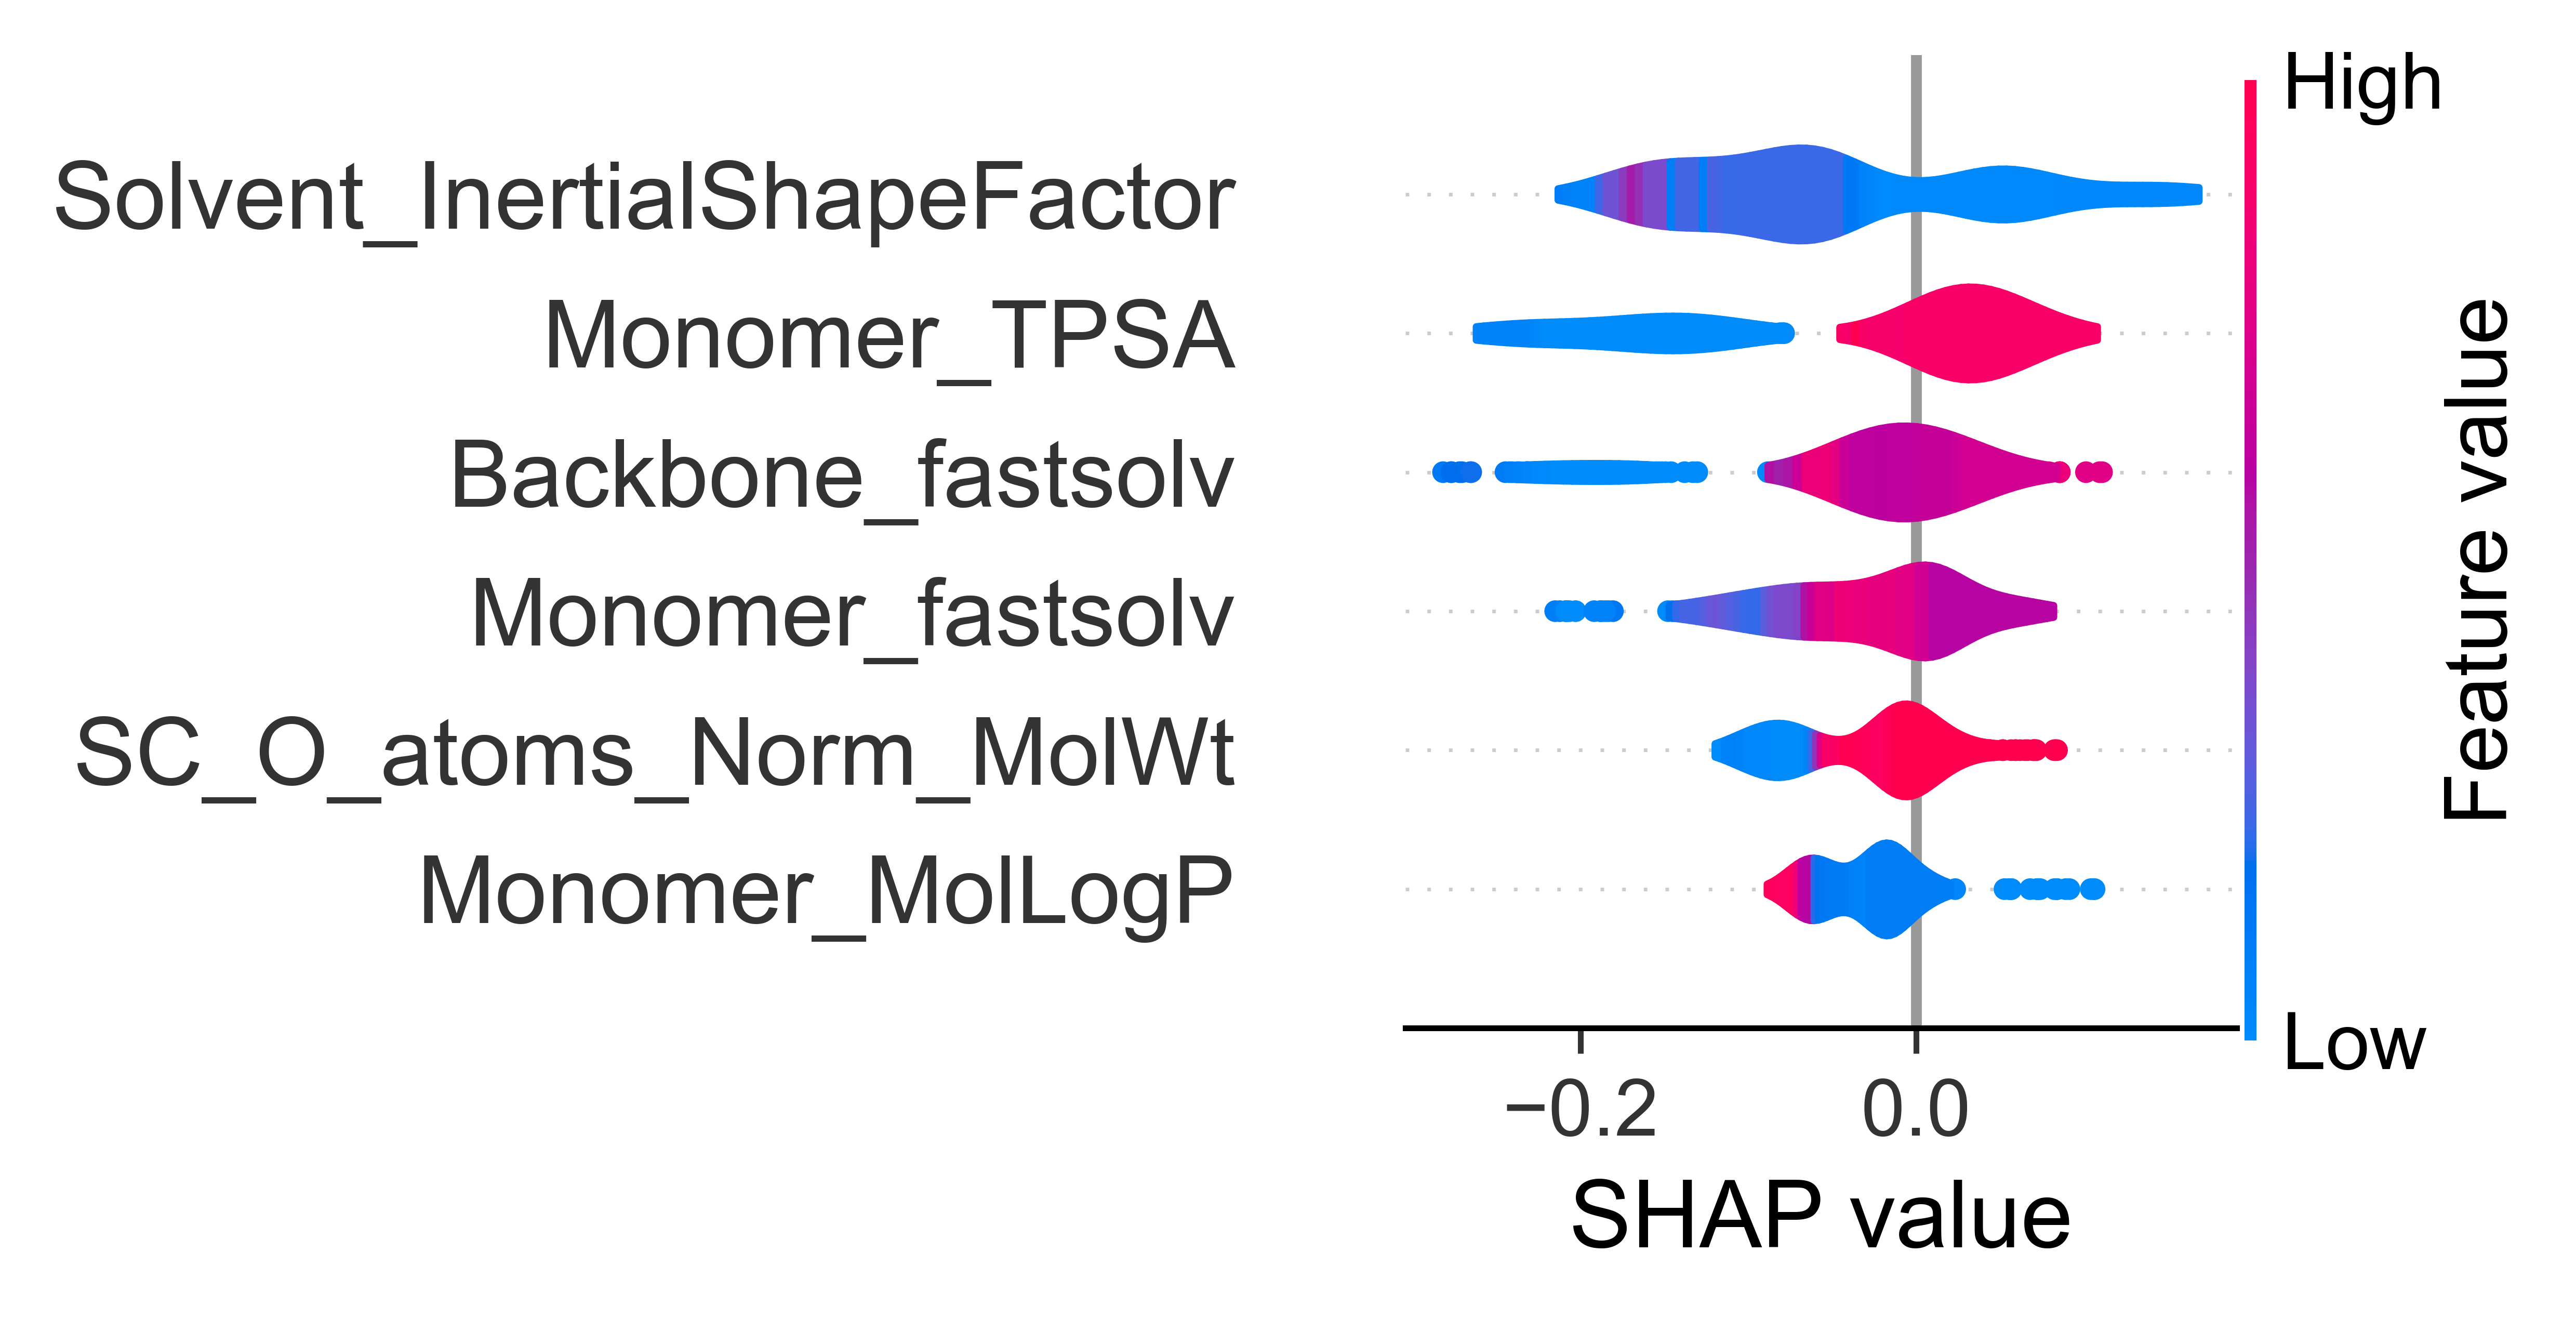

In [5]:
X_thiophene, shap_thiophene = family_shap_values('family_Thiophene family', random_state=43)
draw_family_shap_violin(X_thiophene, shap_thiophene, 'Figure7a.png')


## Figure 7b — Thiophene-family outcome fractions by side-chain oxygen count

This is the third plot from the old Figure3z cell 17.

Thiophene family | unique FASTSOLV positions
Family column: family_Thiophene family
Rows before priority selection: 248
Rows after priority selection: 90
Priority: Strongly Chiral > Weakly Chiral > Isotropic > Aggregated

SC_O_atoms_Norm_MolWt counts:


Category,Strongly Chiral,Weakly Chiral,Isotropic,Aggregated
Feature_bin,,,,
0,0,0,10,18
0–13,3,2,2,20
13–14,5,0,0,17
14+,9,0,0,4


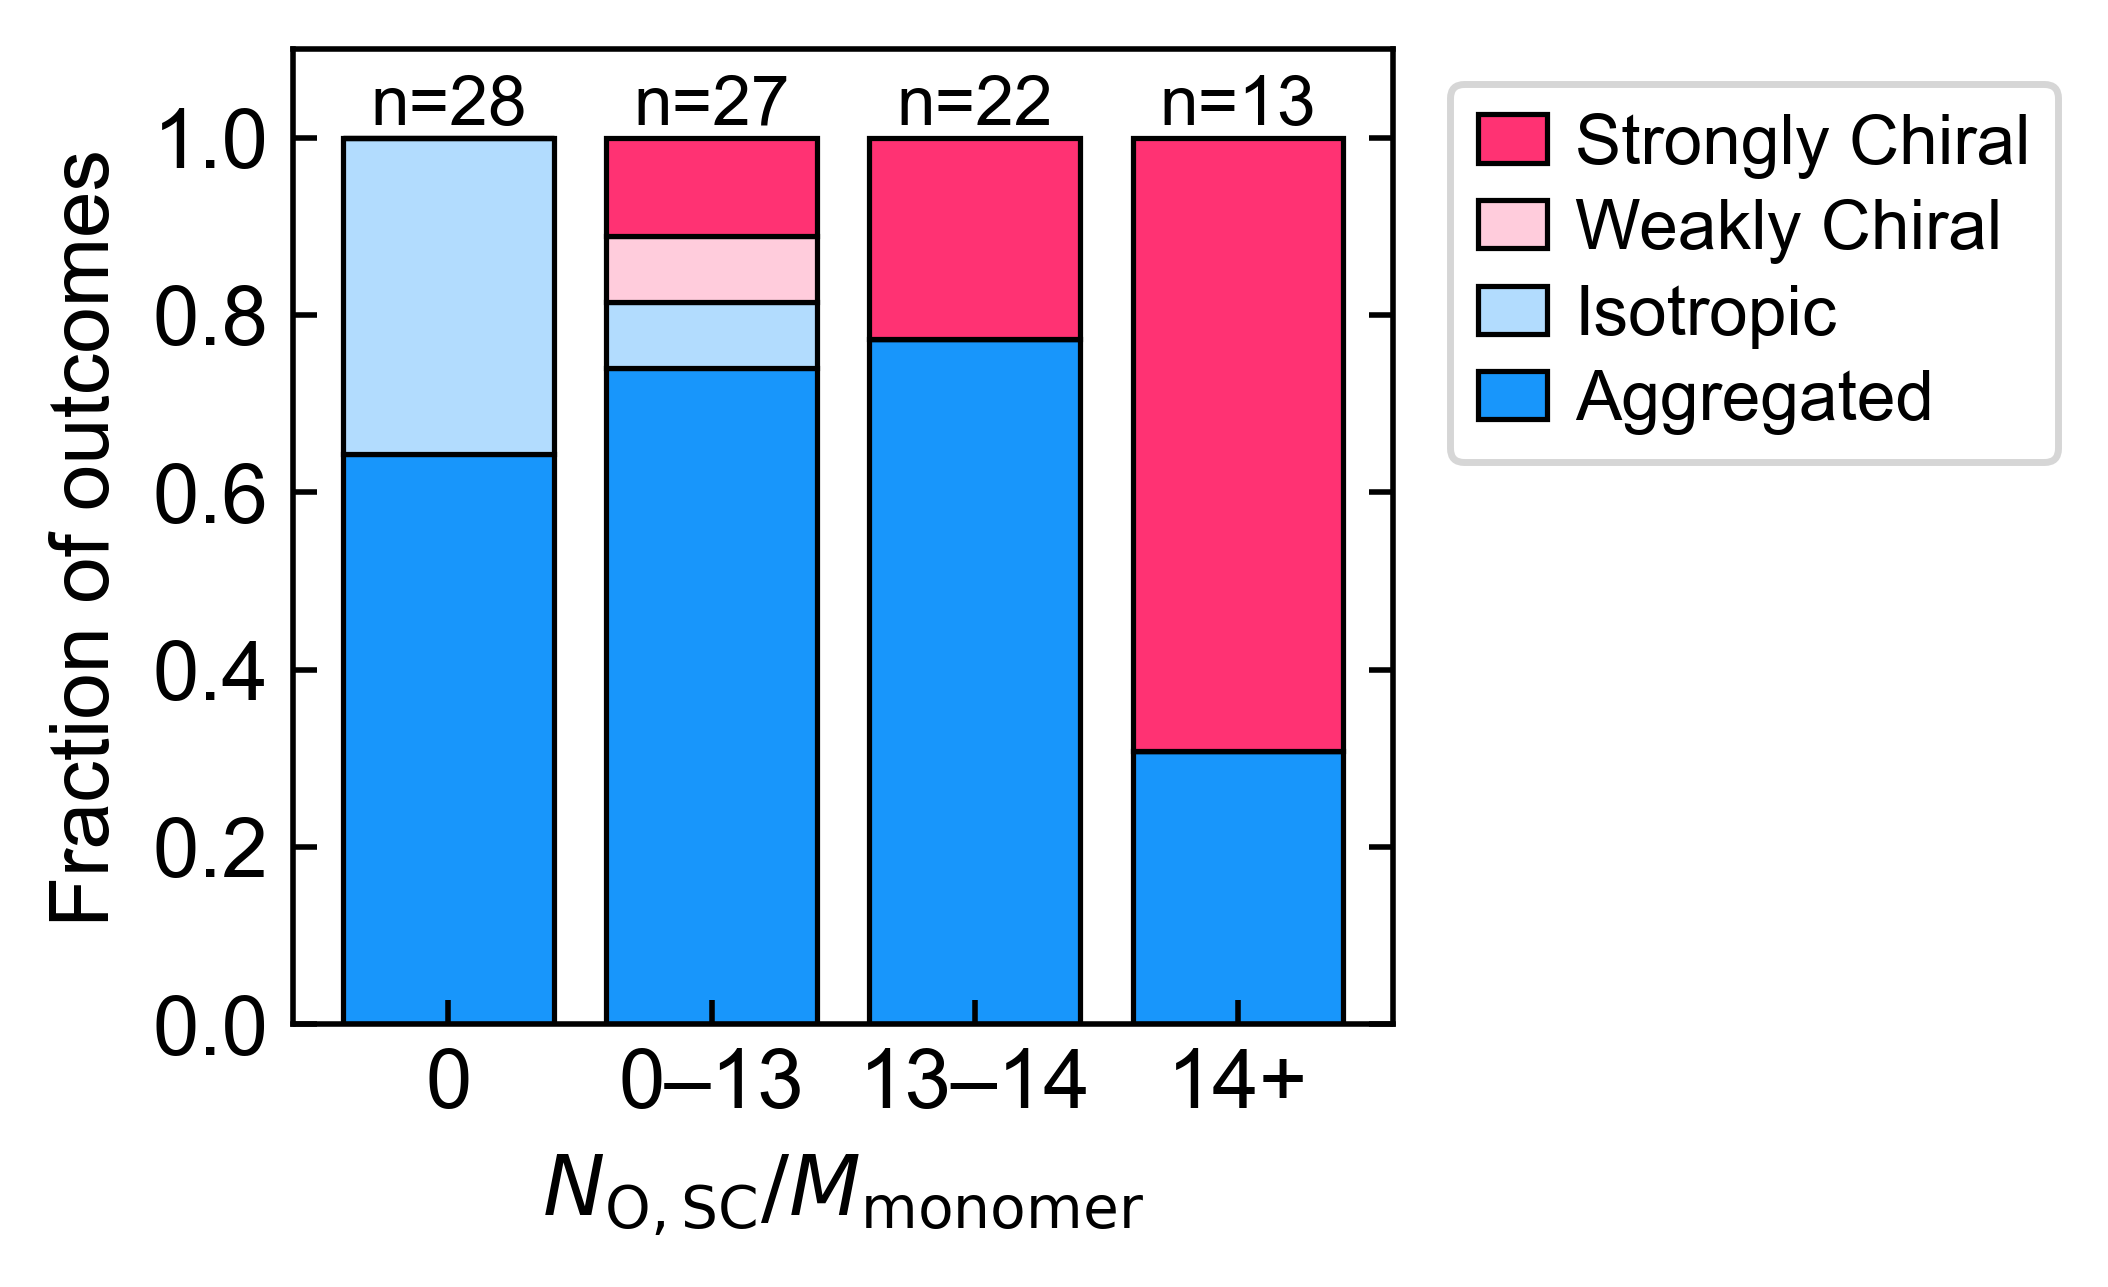

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

BAR_RANGES = {
    "Monomer_TPSA": [0, 0, 75, np.inf],
    "Monomer_MolLogP": [3, 6, 9, 12, np.inf],
    "SC_O_atoms_Norm_MolWt": [0, 0, 13, 14, np.inf],
}

FEATURE_LABELS = {
    "Monomer_TPSA": "Monomer TPSA",
    "Monomer_MolLogP": "Monomer MolLogP",
    "SC_O_atoms_Norm_MolWt":
        r"$N_{\mathrm{O,SC}}/M_{\mathrm{monomer}}$",
}

bar_figsize = (4, 2.5)
bar_width = 0.8
figure_dpi = 500

data_for_plot = d_all_feature

thiophene_candidates = [
    col
    for col in data_for_plot.columns
    if (
        col.startswith("family_")
        and "thiophene" in col.lower()
    )
]

if len(thiophene_candidates) != 1:
    raise KeyError(
        "Expected exactly one thiophene family column; found: "
        f"{thiophene_candidates}"
    )

thiophene_col = thiophene_candidates[0]

required_cols = [
    thiophene_col,
    "Category",
    "FASTSOLV_backbone",
    "FASTSOLV_monomer",
    *BAR_RANGES.keys(),
]

missing_cols = [
    col
    for col in required_cols
    if col not in data_for_plot.columns
]

if missing_cols:
    raise KeyError(
        f"Missing columns: {missing_cols}"
    )

cols_to_keep = required_cols.copy()

if "RowPos" in data_for_plot.columns:
    cols_to_keep.append("RowPos")

thiophene_df = (
    data_for_plot.loc[
        pd.to_numeric(
            data_for_plot[thiophene_col],
            errors="coerce",
        )
        .fillna(0)
        .eq(1),
        cols_to_keep,
    ]
    .copy()
)

for col in [
    "FASTSOLV_backbone",
    "FASTSOLV_monomer",
    *BAR_RANGES.keys(),
]:
    thiophene_df[col] = pd.to_numeric(
        thiophene_df[col],
        errors="coerce",
    )

thiophene_df = (
    thiophene_df
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna(
        subset=[
            "FASTSOLV_backbone",
            "FASTSOLV_monomer",
            "Category",
        ]
    )
    .loc[
        lambda d:
        d["Category"].isin(
            CATEGORY_ORDER
        )
    ]
    .copy()
)

category_priority = {
    category: i
    for i, category in enumerate(
        CATEGORY_ORDER
    )
}

thiophene_df["_Category_priority"] = (
    thiophene_df["Category"]
    .map(category_priority)
)

sort_cols = [
    "FASTSOLV_backbone",
    "FASTSOLV_monomer",
    "_Category_priority",
]

ascending = [
    True,
    True,
    True,
]

if "RowPos" in thiophene_df.columns:
    sort_cols.append("RowPos")
    ascending.append(True)

n_before_priority = len(
    thiophene_df
)

thiophene_unique = (
    thiophene_df
    .sort_values(
        sort_cols,
        ascending=ascending,
    )
    .drop_duplicates(
        subset=[
            "FASTSOLV_backbone",
            "FASTSOLV_monomer",
        ],
        keep="first",
    )
    .reset_index(drop=True)
)

print("=" * 60)
print(
    "Thiophene family | "
    "unique FASTSOLV positions"
)
print(
    "Family column:",
    thiophene_col,
)
print(
    "Rows before priority selection:",
    n_before_priority,
)
print(
    "Rows after priority selection:",
    len(thiophene_unique),
)
print(
    "Priority:",
    " > ".join(CATEGORY_ORDER),
)
print("=" * 60)

CATEGORY_DISPLAY = {
    STRONG: "Strongly Chiral",
    WEAK: "Weakly Chiral",
    ISOTROPIC: "Isotropic",
    AGGREGATION: "Aggregated",
}

def _fmt_edge(value):
    return f"{value:g}"

def make_bin_labels(edges):

    edges = list(edges)

    has_equal_first_bin = (
        len(edges) >= 3
        and edges[0] == edges[1]
    )

    labels = []

    if has_equal_first_bin:

        labels.append(
            _fmt_edge(edges[0])
        )

        interval_edges = edges[1:]

    else:

        interval_edges = edges

    for left, right in zip(
        interval_edges[:-1],
        interval_edges[1:],
    ):

        if np.isneginf(left):

            labels.append(
                f"<{_fmt_edge(right)}"
            )

        elif np.isposinf(right):

            labels.append(
                f"{_fmt_edge(left)}+"
            )

        else:

            labels.append(
                f"{_fmt_edge(left)}–"
                f"{_fmt_edge(right)}"
            )

    return labels

def assign_feature_bins(
    values,
    edges,
):

    edges = list(edges)

    has_equal_first_bin = (
        len(edges) >= 3
        and edges[0] == edges[1]
    )

    bin_labels = make_bin_labels(
        edges
    )

    if not has_equal_first_bin:

        return pd.cut(
            values,
            bins=edges,
            labels=bin_labels,
            right=False,
            include_lowest=True,
        )

    equal_value = edges[0]

    equality_label = (
        _fmt_edge(equal_value)
    )

    interval_edges = edges[1:]

    interval_labels = (
        bin_labels[1:]
    )

    result = pd.Series(
        pd.NA,
        index=values.index,
        dtype="object",
    )

    equal_mask = (
        values.eq(equal_value)
    )

    result.loc[equal_mask] = (
        equality_label
    )

    non_equal_mask = (
        values.notna()
        &
        ~equal_mask
    )

    interval_bins = pd.cut(
        values.loc[non_equal_mask],
        bins=interval_edges,
        labels=interval_labels,
        right=False,
        include_lowest=True,
    )

    result.loc[non_equal_mask] = (
        interval_bins.astype("object")
    )

    return pd.Categorical(
        result,
        categories=bin_labels,
        ordered=True,
    )

def plot_feature_fraction_bar(
    data,
    feature_col,
    bin_edges,
):

    bin_labels = make_bin_labels(
        bin_edges
    )

    bar_df = (
        data[
            [
                feature_col,
                "Category",
            ]
        ]
        .dropna()
        .copy()
    )

    bar_df["Feature_bin"] = assign_feature_bins(
        bar_df[feature_col],
        bin_edges,
    )
    bar_df = (
        bar_df
        .dropna(
            subset=["Feature_bin"]
        )
    )

    counts = (
        pd.crosstab(
            bar_df["Feature_bin"],
            bar_df["Category"],
        )
        .reindex(
            index=bin_labels,
            columns=CATEGORY_ORDER,
            fill_value=0,
        )
    )

    n_per_bin = counts.sum(
        axis=1
    )

    fractions = (
        counts
        .div(
            n_per_bin.replace(
                0,
                np.nan,
            ),
            axis=0,
        )
        .fillna(0)
    )

    print(
        f"\n{feature_col} counts:"
    )

    display(counts)

    fig, ax = plt.subplots(
        figsize=bar_figsize,
        dpi=figure_dpi,
    )

    x = np.arange(
        len(bin_labels)
    )

    bottom = np.zeros(
        len(bin_labels)
    )

    for category in reversed(
        CATEGORY_ORDER
    ):

        values = (
            fractions[category]
            .to_numpy()
        )

        ax.bar(
            x,
            values,
            bottom=bottom,
            width=bar_width,
            color=
                CATEGORY_TO_COLOR[
                    category
                ],
            edgecolor="black",
            linewidth=0.75,
        )

        bottom += values

    for i, n in enumerate(
        n_per_bin
    ):

        ax.text(
            i,
            1.0,
            f"n={int(n)}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    ax.set_xlabel(
        FEATURE_LABELS[
            feature_col
        ]
    )

    ax.set_ylabel(
        "Fraction of outcomes"
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        bin_labels
    )

    ax.set_ylim(
        0,
        1.1,
    )

    ax.set_yticks(
        np.arange(
            0,
            1.01,
            0.2,
        )
    )

    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=False,
        right=True,
    )

    legend_handles = [
        Patch(
            facecolor=
                CATEGORY_TO_COLOR[
                    category
                ],
            edgecolor="black",
            linewidth=0.75,
            label=
                CATEGORY_DISPLAY[
                    category
                ],
        )
        for category in CATEGORY_ORDER
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(
            1.02,
            1.0,
        ),
        frameon=True,
        fontsize=10,
        handlelength=1.0,
        handletextpad=0.4,
        borderpad=0.4,
        labelspacing=0.3,
    )

    fig.subplots_adjust(
        left=0.20,
        right=0.75,
        bottom=0.18,
        top=0.96,
    )

    fig.savefig(FIGURE_DIR / 'Figure7b.png', dpi=figure_dpi, bbox_inches='tight')

    plt.show()

plot_feature_fraction_bar(
    thiophene_unique,
    'SC_O_atoms_Norm_MolWt',
    BAR_RANGES['SC_O_atoms_Norm_MolWt'],
)


## Figure 7c — NDI-family SHAP violin

family_NDI family: 143 rows; positive fraction=0.4685
Top six features:
Concentration_mg_mL              0.145292
MW_Mn                            0.068584
Solvent_MolLogP                  0.033708
SC_n_branch_points_Norm_MolWt    0.033669
PDI                              0.032028
R_atoms_C                        0.027950


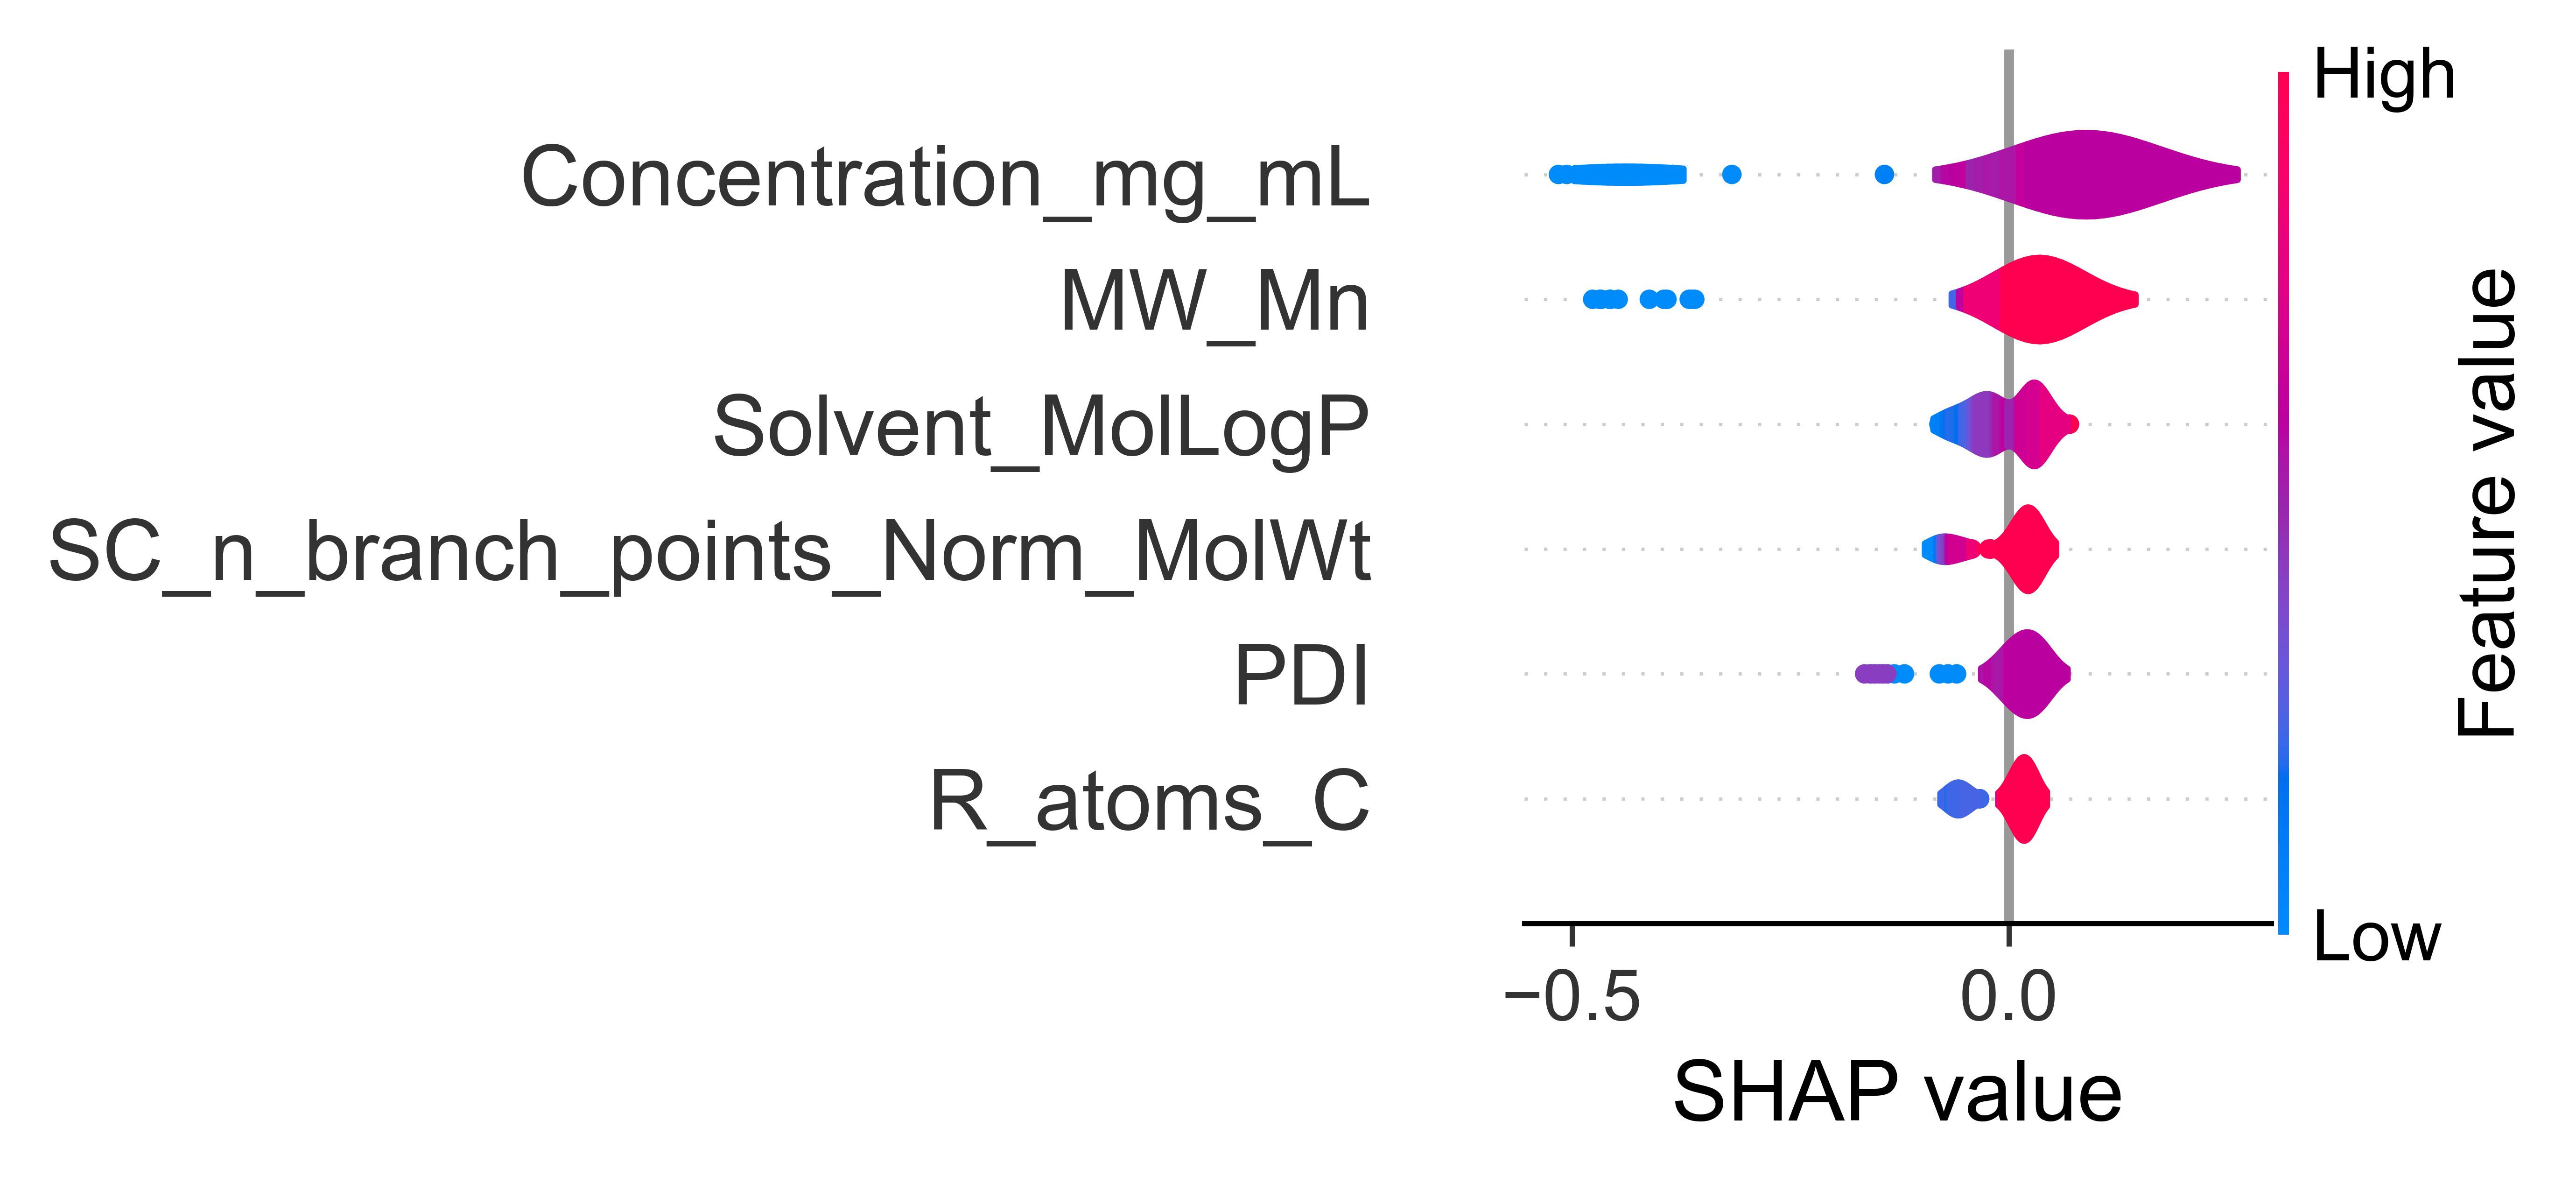

In [7]:
X_ndi, shap_ndi = family_shap_values('family_NDI family', random_state=42)
draw_family_shap_violin(X_ndi, shap_ndi, 'Figure7c.png')


## Figure 7d — N2200 in chlorobenzene

N2200 in Chlorobenzene
Rows before position selection: 49
Rows after position selection: 27
Removed overlapping points: 22
Priority: Strongly chiral > Weakly chiral > Isotropic > Aggregated

Category counts:
Category
Strongly Chiral    17
Weakly Chiral       0
Isotropic          10
Aggregated          0
Name: count, dtype: int64


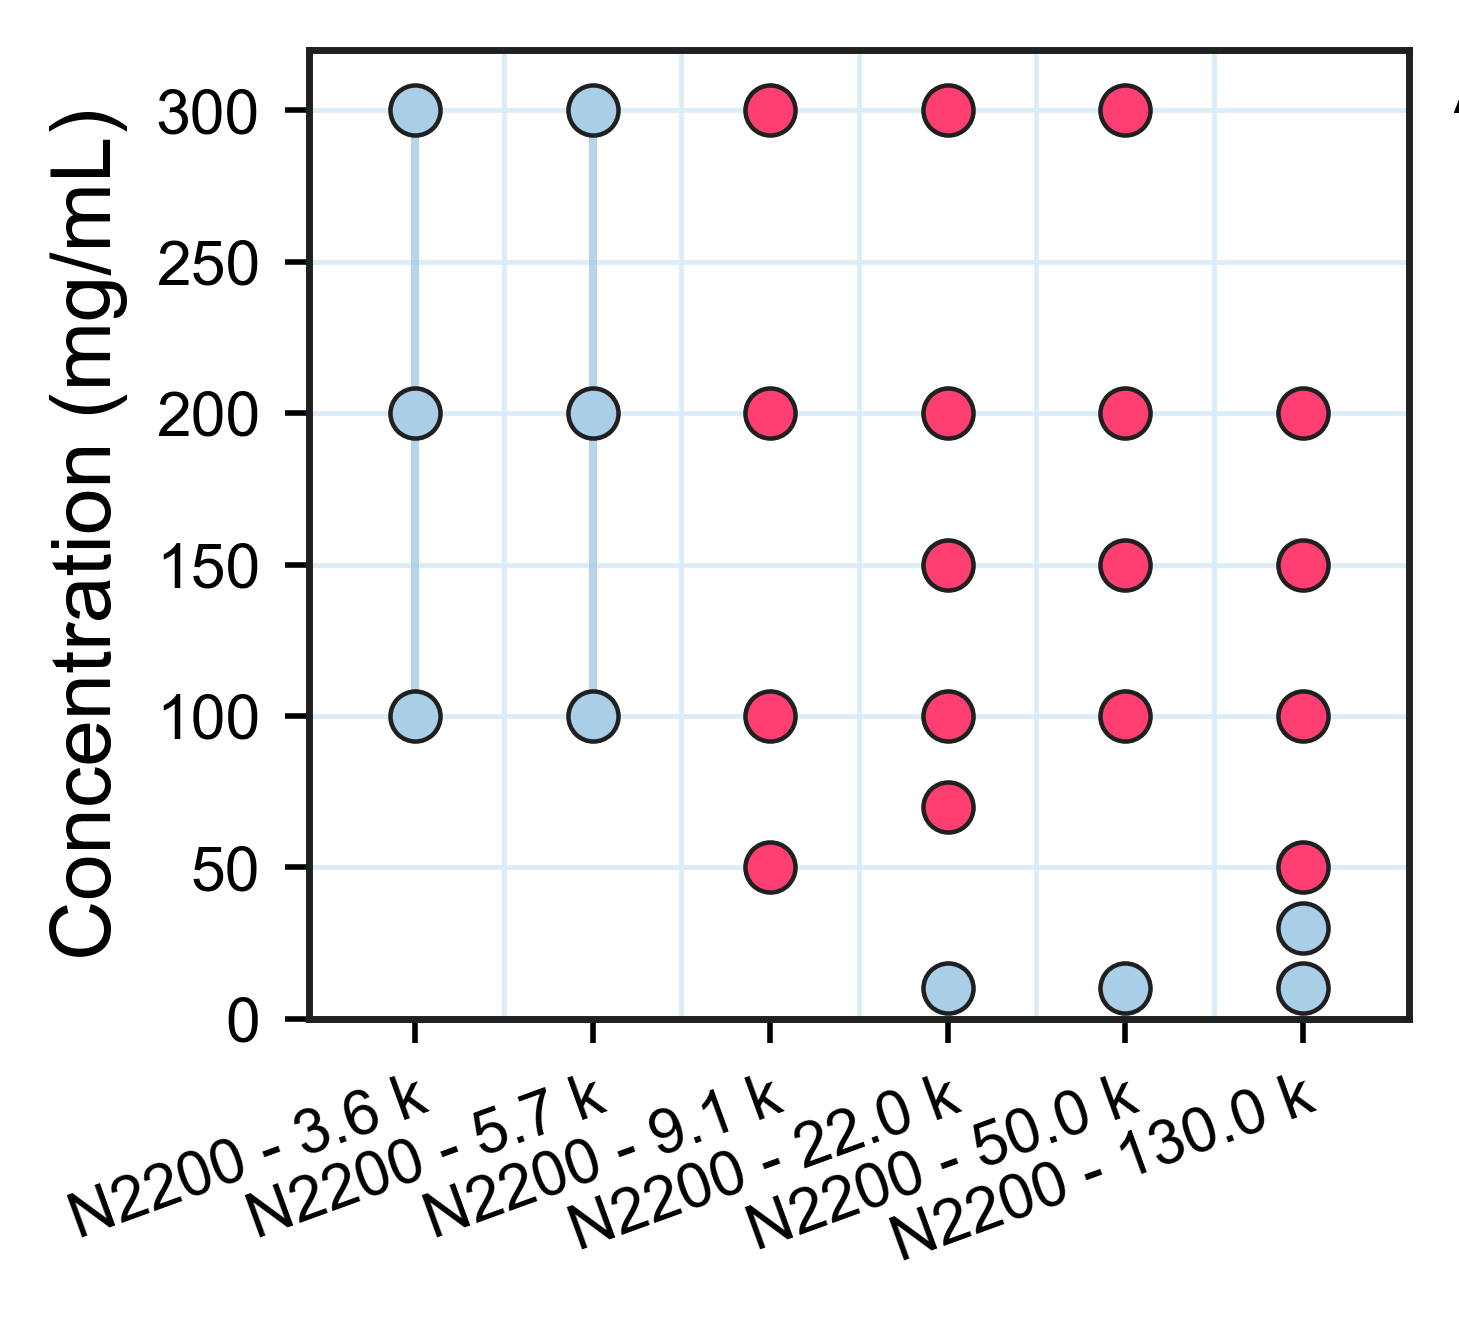

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

FONT_SIZE_BASE = 10
FONT_SIZE_AXIS_LABEL = 12
FONT_SIZE_XTICK = 9
FONT_SIZE_YTICK = 9
FONT_SIZE_SERIES_TITLE = 9
FONT_SIZE_LEGEND = 8
FONT_SIZE_LEGEND_TITLE = 8

plt.rcParams.update({
    "font.size": FONT_SIZE_BASE,
    "axes.labelsize": FONT_SIZE_AXIS_LABEL,
    "xtick.labelsize": FONT_SIZE_XTICK,
    "ytick.labelsize": FONT_SIZE_YTICK,
    "legend.fontsize": FONT_SIZE_LEGEND,
    "legend.title_fontsize": FONT_SIZE_LEGEND_TITLE,
})

data_for_plot = d_all_feature

figure_size = (3.55, 2.85)
figure_dpi = 500

point_size = 52
point_edge_width = 0.65

concentration_ylim = (0, 320)

concentration_yticks = np.arange(
    0,
    301,
    50,
)

x_tick_rotation = 20

POLYMER_ORDER = [
    "N2200 - 3.6 k",
    "N2200 - 5.7 k",
    "N2200 - 9.1 k",
    "N2200 - 22.0 k",
    "N2200 - 50.0 k",
    "N2200 - 130.0 k",
]

POLYMER_DISPLAY_LABELS = {
    polymer: polymer
    for polymer in POLYMER_ORDER
}

MW_SERIES_START = None

mw_series_title = (
    "N2200 molecular-weight series"
)

shade_color = "#EAF4F9"

y_axis_label = (
    "Concentration (mg/mL)"
)

draw_condition_lines = True

condition_line_width = 1.15
condition_line_alpha = 0.85

STRONG = "Strongly Chiral"
WEAK = "Weakly Chiral"
ISOTROPIC = "Isotropic"
AGGREGATION = "Aggregated"

CATEGORY_ORDER = [
    STRONG,
    WEAK,
    ISOTROPIC,
    AGGREGATION,
]

CATEGORY_DISPLAY = {
    STRONG: "Strongly chiral",
    WEAK: "Weakly chiral",
    ISOTROPIC: "Isotropic",
    AGGREGATION: "Aggregated",
}

CATEGORY_COLORS = {
    STRONG: "#FF3F72",
    WEAK: "#FF9AB2",
    ISOTROPIC: "#A9CEE7",
    AGGREGATION: "#1596F5",
}

OUTCOME_LEGEND_ORDER = [
    STRONG,
    WEAK,
    ISOTROPIC,
    AGGREGATION,
]

category_priority = {
    category: i
    for i, category in enumerate(
        CATEGORY_ORDER
    )
}

required_cols = [
    "Polymer name",
    "Solvent",
    "Concentration_mg_mL",
    "Category",
]

missing_cols = [
    col
    for col in required_cols
    if col not in data_for_plot.columns
]

if missing_cols:

    raise KeyError(
        f"Missing columns: {missing_cols}"
    )

cols_to_keep = (
    required_cols.copy()
)

if "RowPos" in data_for_plot.columns:

    cols_to_keep.append(
        "RowPos"
    )

n2200_cb_df = (
    data_for_plot[
        cols_to_keep
    ]
    .copy()
)

for col in [
    "Polymer name",
    "Solvent",
]:

    n2200_cb_df[col] = (
        n2200_cb_df[col]
        .astype(str)
        .str.strip()
        .str.replace(
            r"\s+",
            " ",
            regex=True,
        )
    )

n2200_cb_df[
    "Concentration_mg_mL"
] = pd.to_numeric(
    n2200_cb_df[
        "Concentration_mg_mL"
    ],
    errors="coerce",
)

n2200_cb_df = (
    n2200_cb_df
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna(
        subset=[
            "Polymer name",
            "Solvent",
            "Concentration_mg_mL",
            "Category",
        ]
    )
    .loc[
        lambda d:
        d["Category"].isin(
            CATEGORY_ORDER
        )
    ]
    .copy()
)

n2200_cb_df[
    "_Solvent_normalized"
] = (
    n2200_cb_df[
        "Solvent"
    ]
    .str.lower()
    .str.replace(
        r"[\s_\-]+",
        "",
        regex=True,
    )
)

chlorobenzene_mask = (
    n2200_cb_df[
        "_Solvent_normalized"
    ]
    .isin(
        [
            "chlorobenzene",
            "cb",
        ]
    )
)

n2200_cb_df = (
    n2200_cb_df.loc[
        chlorobenzene_mask
        &
        n2200_cb_df[
            "Polymer name"
        ]
        .isin(
            POLYMER_ORDER
        )
    ]
    .copy()
)

if len(n2200_cb_df) == 0:

    raise ValueError(
        "No N2200 + Chlorobenzene rows found. "
        "Check the polymer and solvent names."
    )

n2200_cb_df[
    "_Category_priority"
] = (
    n2200_cb_df[
        "Category"
    ]
    .map(category_priority)
)

sort_cols = [
    "Polymer name",
    "Concentration_mg_mL",
    "_Category_priority",
]

ascending = [
    True,
    True,
    True,
]

if "RowPos" in n2200_cb_df.columns:

    sort_cols.append(
        "RowPos"
    )

    ascending.append(
        True
    )

n_before_selection = len(
    n2200_cb_df
)

n2200_cb_unique = (
    n2200_cb_df
    .sort_values(
        sort_cols,
        ascending=ascending,
    )
    .drop_duplicates(
        subset=[
            "Polymer name",
            "Concentration_mg_mL",
        ],
        keep="first",
    )
    .reset_index(drop=True)
)

print("=" * 65)
print("N2200 in Chlorobenzene")
print("=" * 65)

print(
    "Rows before position selection:",
    n_before_selection,
)

print(
    "Rows after position selection:",
    len(n2200_cb_unique),
)

print(
    "Removed overlapping points:",
    n_before_selection
    -
    len(n2200_cb_unique),
)

print(
    "Priority:",
    " > ".join(
        CATEGORY_DISPLAY[c]
        for c in CATEGORY_ORDER
    ),
)

print(
    "\nCategory counts:"
)

print(
    n2200_cb_unique[
        "Category"
    ]
    .value_counts()
    .reindex(
        CATEGORY_ORDER,
        fill_value=0,
    )
)

detected_polymers = set(
    n2200_cb_unique[
        "Polymer name"
    ]
)

polymer_order = [
    polymer
    for polymer in POLYMER_ORDER
    if polymer in detected_polymers
]

if len(polymer_order) == 0:

    raise ValueError(
        "None of the requested N2200 polymers "
        "were found."
    )

missing_polymers = [
    polymer
    for polymer in POLYMER_ORDER
    if polymer not in detected_polymers
]

if missing_polymers:

    print(
        "\nN2200 polymers without "
        "Chlorobenzene data:"
    )

    for polymer in missing_polymers:

        print(
            " -",
            polymer,
        )

polymer_to_x = {
    polymer: i
    for i, polymer in enumerate(
        polymer_order
    )
}

n2200_cb_unique = (
    n2200_cb_unique.loc[
        n2200_cb_unique[
            "Polymer name"
        ]
        .isin(polymer_order)
    ]
    .copy()
)

n2200_cb_unique[
    "_Plot_x"
] = (
    n2200_cb_unique[
        "Polymer name"
    ]
    .map(polymer_to_x)
)

fig, ax = plt.subplots(
    figsize=figure_size,
    dpi=figure_dpi,
)

ax.set_facecolor(
    "white"
)

if MW_SERIES_START in polymer_to_x:

    mw_start_index = (
        polymer_to_x[
            MW_SERIES_START
        ]
    )

    shade_start = (
        mw_start_index
        - 0.5
    )

    shade_end = (
        len(polymer_order)
        - 0.5
    )

    ax.axvspan(
        shade_start,
        shade_end,
        facecolor=shade_color,
        edgecolor="none",
        alpha=1.0,
        zorder=0.1,
    )

    title_x = (
        shade_start
        +
        shade_end
    ) / 2

    ax.text(
        title_x,
        0.985,
        mw_series_title,
        transform=
            ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=
            FONT_SIZE_SERIES_TITLE,
        zorder=10,
    )

if draw_condition_lines:

    for polymer, sub in (
        n2200_cb_unique
        .groupby(
            "Polymer name",
            sort=False,
        )
    ):
        if polymer == "N2200 - 130.0 k":
            continue

        sub = (
            sub
            .sort_values(
                "Concentration_mg_mL"
            )
            .reset_index(drop=True)
        )

        x_position = (
            polymer_to_x[
                polymer
            ]
        )

        for i in range(
            len(sub) - 1
        ):

            lower_point = (
                sub.iloc[i]
            )

            upper_point = (
                sub.iloc[i + 1]
            )

            lower_category = (
                lower_point[
                    "Category"
                ]
            )

            upper_category = (
                upper_point[
                    "Category"
                ]
            )

            same_category = (
                lower_category
                ==
                upper_category
            )

            allowed_category = (
                lower_category
                in [
                    ISOTROPIC,
                    AGGREGATION,
                ]
            )

            if (
                same_category
                and
                allowed_category
            ):

                ax.plot(
                    [
                        x_position,
                        x_position,
                    ],
                    [
                        lower_point[
                            "Concentration_mg_mL"
                        ],
                        upper_point[
                            "Concentration_mg_mL"
                        ],
                    ],
                    color=
                        CATEGORY_COLORS[
                            lower_category
                        ],
                    linewidth=
                        condition_line_width,
                    alpha=
                        condition_line_alpha,
                    solid_capstyle="round",
                    zorder=2,
                )

for category in reversed(
    CATEGORY_ORDER
):

    sub = (
        n2200_cb_unique.loc[
            n2200_cb_unique[
                "Category"
            ]
            .eq(category)
        ]
    )

    if len(sub) == 0:

        continue

    ax.scatter(
        sub["_Plot_x"],
        sub[
            "Concentration_mg_mL"
        ],
        s=point_size,
        marker="o",
        facecolor=
            CATEGORY_COLORS[
                category
            ],
        edgecolor="#202020",
        linewidth=
            point_edge_width,
        alpha=1.0,
        zorder=5,
    )

polymer_display_labels = [
    POLYMER_DISPLAY_LABELS.get(
        polymer,
        polymer,
    )
    for polymer in polymer_order
]

ax.set_xticks(
    np.arange(
        len(polymer_order)
    )
)

ax.set_xticklabels(
    polymer_display_labels,
    fontsize=FONT_SIZE_XTICK,
    rotation=x_tick_rotation,
    ha="right",
    va="top",
    rotation_mode="anchor",
)

ax.set_xlim(
    -0.60,
    len(polymer_order) - 0.40,
)

ax.set_ylim(
    concentration_ylim
)

ax.set_yticks(
    concentration_yticks
)

'''
ax.set_xlabel(
    x_axis_label,
    fontsize=FONT_SIZE_AXIS_LABEL,
)
'''

ax.set_ylabel(
    y_axis_label,
    fontsize=FONT_SIZE_AXIS_LABEL,
)

ax.tick_params(
    axis="y",
    which="major",
    labelsize=FONT_SIZE_YTICK,
    direction="out",
    right=False,
)

ax.tick_params(
    axis="x",
    which="major",
    labelsize=FONT_SIZE_XTICK,
    direction="out",
    top=False,
)

ax.grid(False)

ax.grid(
    axis="y",
    which="major",
    color="#D9ECF7",
    linewidth=0.7,
    alpha=0.95,
    zorder=0,
)

polymer_boundaries = (
    np.arange(
        len(polymer_order) - 1
    )
    +
    0.5
)

ax.set_xticks(
    polymer_boundaries,
    minor=True,
)

ax.grid(
    axis="x",
    which="minor",
    color="#D9ECF7",
    linewidth=0.7,
    alpha=0.95,
    zorder=0,
)

ax.tick_params(
    axis="x",
    which="minor",
    bottom=False,
    top=False,
)

for spine in ax.spines.values():

    spine.set_color(
        "#202020"
    )

    spine.set_linewidth(
        1.0
    )

present_categories = [
    category
    for category in OUTCOME_LEGEND_ORDER
    if (
        n2200_cb_unique[
            "Category"
        ]
        .eq(category)
        .any()
    )
]

outcome_handles = [
    Line2D(
        [0],
        [0],
        linestyle="None",
        marker="o",
        markersize=6,
        markerfacecolor=
            CATEGORY_COLORS[
                category
            ],
        markeredgecolor="#202020",
        markeredgewidth=0.65,
        label=
            CATEGORY_DISPLAY[
                category
            ],
    )
    for category in present_categories
]

outcome_legend = ax.legend(
    handles=outcome_handles,
    title="Assembly outcome",
    loc="upper left",
    bbox_to_anchor=(
        1.02,
        1.00,
    ),
    frameon=False,
    fontsize=FONT_SIZE_LEGEND,
    title_fontsize=
        FONT_SIZE_LEGEND_TITLE,
    handlelength=1.0,
    handletextpad=0.5,
    labelspacing=0.25,
    borderaxespad=0,
)

ax.add_artist(
    outcome_legend
)

solvent_handle = Line2D(
    [0],
    [0],
    linestyle="None",
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgecolor="#202020",
    markeredgewidth=0.8,
    label="Chlorobenzene",
)

'''
ax.legend(
    handles=[
        solvent_handle
    ],
    title="Solvent",
    loc="upper left",
    bbox_to_anchor=(
        1.02,
        0.62,
    ),
    frameon=False,
    fontsize=FONT_SIZE_LEGEND,
    title_fontsize=
        FONT_SIZE_LEGEND_TITLE,
    handlelength=1.0,
    handletextpad=0.5,
    labelspacing=0.25,
    borderaxespad=0,
)
'''

fig.subplots_adjust(
    left=0.12,
    right=0.74,
    bottom=0.28,
    top=0.96,
)

fig.savefig(FIGURE_DIR / 'Figure7d.png', dpi=figure_dpi, bbox_inches='tight')
plt.show()
